<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/W2_Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pd.set_option("display.max_columns", None)

# Better plot size
plt.rcParams["figure.figsize"] = (15,5)

In [4]:
df = pd.read_csv(
    "/content/drive/MyDrive/PRISM/raw_data/TCS.NS.csv",
    header=[0,1]
)
df.columns = df.columns.get_level_values(0)

# Remove the first row (which contains "Date")
df = df.iloc[1:].reset_index(drop=True)
df.rename(columns={"Price": "Date"}, inplace=True)

In [5]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2019-01-01,1561.000610,1566.907236,1546.397979,1555.422052,1094883.0
1,2019-01-02,1577.817749,1586.964795,1558.703087,1562.804937,2100463.0
2,2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668.0
3,2019-01-04,1539.711792,1559.687786,1510.301540,1558.703382,4280862.0
4,2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423.0


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True) #setting date as index

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1481 entries, 2019-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1481 non-null   float64
 1   High    1481 non-null   float64
 2   Low     1481 non-null   float64
 3   Open    1481 non-null   float64
 4   Volume  1481 non-null   float64
dtypes: float64(5)
memory usage: 69.4 KB


In [8]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-01,1561.000610,1566.907236,1546.397979,1555.422052,1094883.0
2019-01-02,1577.817749,1586.964795,1558.703087,1562.804937,2100463.0
2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668.0
2019-01-04,1539.711792,1559.687786,1510.301540,1558.703382,4280862.0
2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423.0


In [9]:
df.isnull().sum()

,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [11]:
df.describe()

,Close,High,Low,Open,Volume
count,1481.000000,1481.000000,1481.000000,1481.000000,1.481000e+03
mean,2751.234888,2778.450886,2724.831639,2752.136324,2.745963e+06
std,735.664131,739.792090,731.702866,735.225585,1.660880e+06
min,1403.242554,1445.347957,1282.137060,1337.511764,1.548950e+05
25%,1901.627075,1923.109589,1878.140313,1900.743829,1.711510e+06
50%,2889.345703,2914.741030,2863.072675,2889.963449,2.316539e+06
75%,3231.117920,3254.525623,3205.212637,3234.931844,3.224657e+06
max,4253.906250,4289.871200,4214.905946,4274.691846,1.983933e+07


In [12]:
df.shape

(1481, 5)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.dropna()

In [15]:
df["return"] = df["Close"].pct_change()

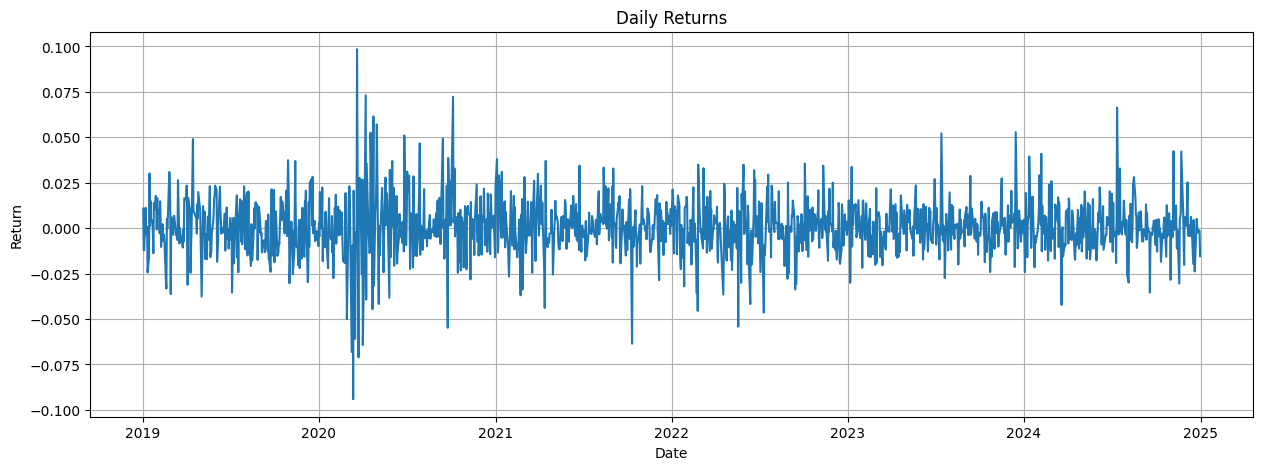

In [20]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

In [17]:
df["log_return"] = np.log(      #ts is the most imp concept of how to calculate returns
    df["Close"] /
    df["Close"].shift(1)
)

In [18]:
df[["Close","return"]].head(10)

,Close,return
Date,,
2019-01-01,1561.000610,NaN
2019-01-02,1577.817749,0.010773
2019-01-03,1558.662354,-0.012140
2019-01-04,1539.711792,-0.012158
2019-01-07,1556.980347,0.011215
2019-01-08,1553.412231,-0.002292
2019-01-09,1547.997559,-0.003486
2019-01-10,1549.310303,0.000848
2019-01-11,1511.572998,-0.024357


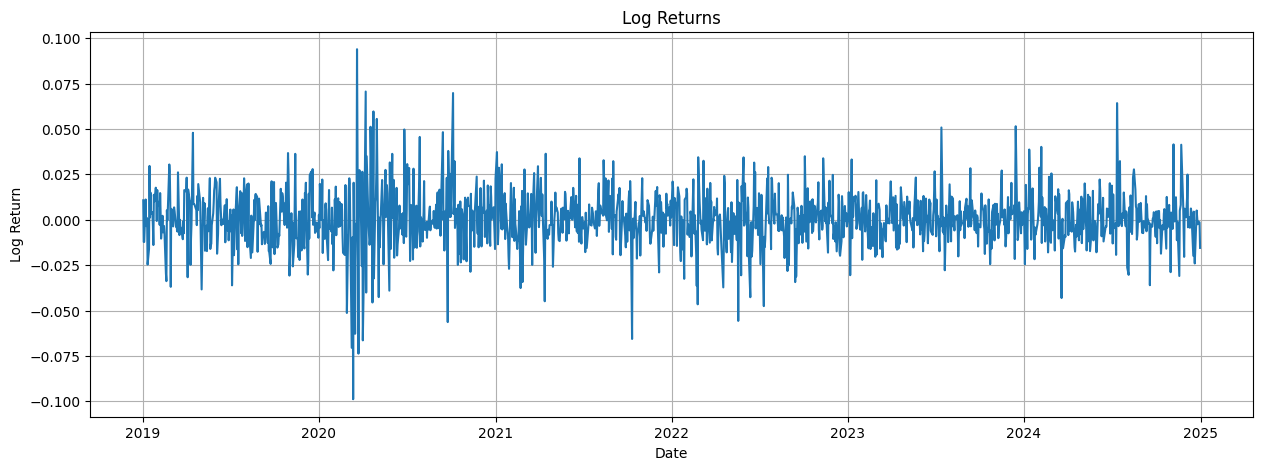

In [21]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["log_return"])
plt.title("Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

In [23]:
print(df[["Close", "return", "log_return"]].head(10))

                  Close    return  log_return
Date                                         
2019-01-01  1561.000610       NaN         NaN
2019-01-02  1577.817749  0.010773    0.010716
2019-01-03  1558.662354 -0.012140   -0.012215
2019-01-04  1539.711792 -0.012158   -0.012233
2019-01-07  1556.980347  0.011215    0.011153
2019-01-08  1553.412231 -0.002292   -0.002294
2019-01-09  1547.997559 -0.003486   -0.003492
2019-01-10  1549.310303  0.000848    0.000848
2019-01-11  1511.572998 -0.024357   -0.024659
2019-01-14  1487.536133 -0.015902   -0.016030


In [24]:
print(df[["return", "log_return"]].describe())

            return   log_return
count  1480.000000  1480.000000
mean      0.000724     0.000607
std       0.015253     0.015250
min      -0.094104    -0.098830
25%      -0.006960    -0.006984
50%       0.000518     0.000518
75%       0.008536     0.008500
max       0.098451     0.093901


In [26]:
df["MA5"] = df["Close"].rolling(window=5).mean()

# 10-Day Moving Average
df["MA10"] = df["Close"].rolling(window=10).mean()

# 20-Day Moving Average
df["MA20"] = df["Close"].rolling(window=20).mean()

In [27]:
# Check
df[["Close", "MA5", "MA10", "MA20"]].head(25)

,Close,MA5,MA10,MA20
Date,,,,
2019-01-01,1561.000610,NaN,NaN,NaN
2019-01-02,1577.817749,NaN,NaN,NaN
2019-01-03,1558.662354,NaN,NaN,NaN
2019-01-04,1539.711792,NaN,NaN,NaN
2019-01-07,1556.980347,1558.834570,NaN,NaN
2019-01-08,1553.412231,1557.316895,NaN,NaN
2019-01-09,1547.997559,1551.352856,NaN,NaN
2019-01-10,1549.310303,1549.482446,NaN,NaN
2019-01-11,1511.572998,1543.854687,NaN,NaN


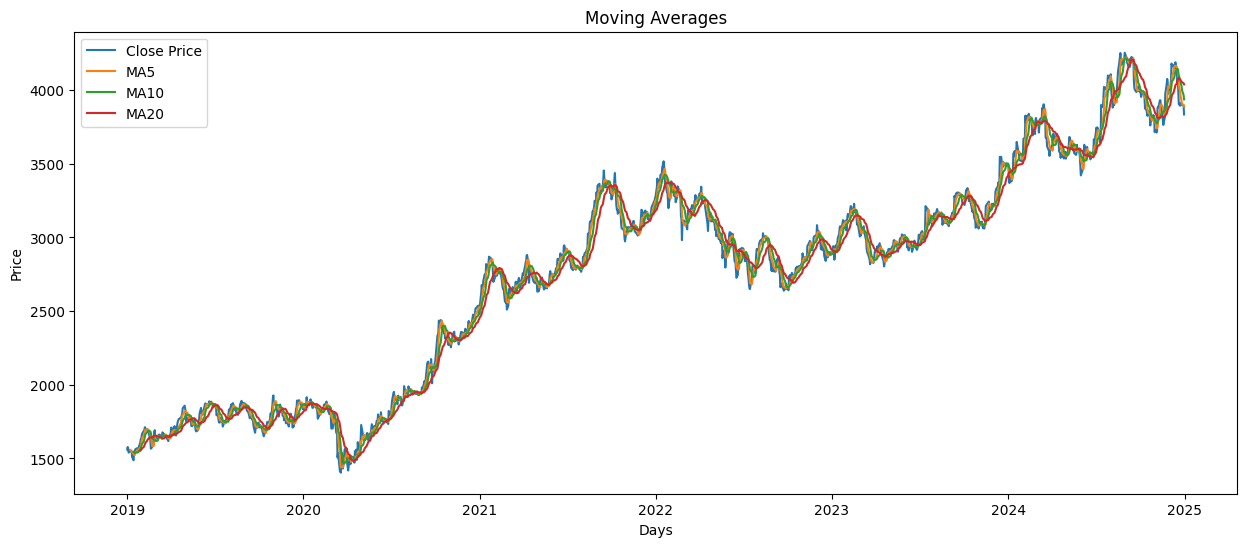

In [28]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA5"], label="MA5")
plt.plot(df["MA10"], label="MA10")
plt.plot(df["MA20"], label="MA20")

plt.title("Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()

plt.show()

In [29]:
# 20-Day Rolling Volatility
df["Volatility"] = df["return"].rolling(window=20).std()

# Check
df[["return", "Volatility"]].head(25)

,return,Volatility
Date,,
2019-01-01,NaN,NaN
2019-01-02,0.010773,NaN
2019-01-03,-0.012140,NaN
2019-01-04,-0.012158,NaN
2019-01-07,0.011215,NaN
2019-01-08,-0.002292,NaN
2019-01-09,-0.003486,NaN
2019-01-10,0.000848,NaN
2019-01-11,-0.024357,NaN


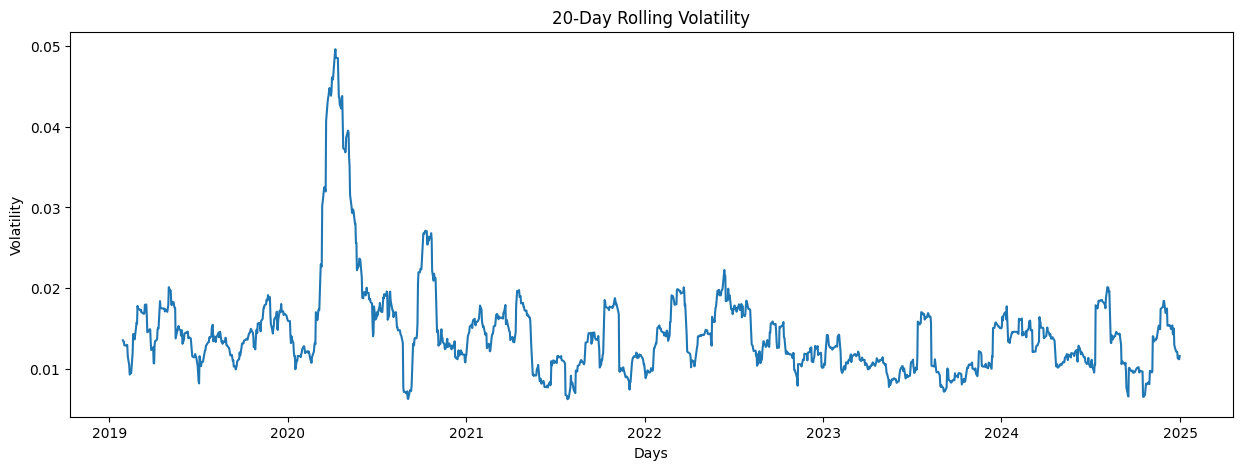

In [30]:
plt.figure(figsize=(15,5))

plt.plot(df["Volatility"])

plt.title("20-Day Rolling Volatility")
plt.xlabel("Days")
plt.ylabel("Volatility")

plt.show()

In [33]:
df["Volume_Change"] = df["Volume"].pct_change()
df["Volume_MA20"] = df["Volume"].rolling(window=20).mean()
df[["Volume", "Volume_Change", "Volume_MA20"]].head(25)

,Volume,Volume_Change,Volume_MA20
Date,,,
2019-01-01,1094883.0,NaN,NaN
2019-01-02,2100463.0,0.918436,NaN
2019-01-03,2611668.0,0.243377,NaN
2019-01-04,4280862.0,0.639129,NaN
2019-01-07,1856423.0,-0.566344,NaN
2019-01-08,1691756.0,-0.088701,NaN
2019-01-09,2414376.0,0.427142,NaN
2019-01-10,3053461.0,0.264700,NaN
2019-01-11,9209862.0,2.016204,NaN


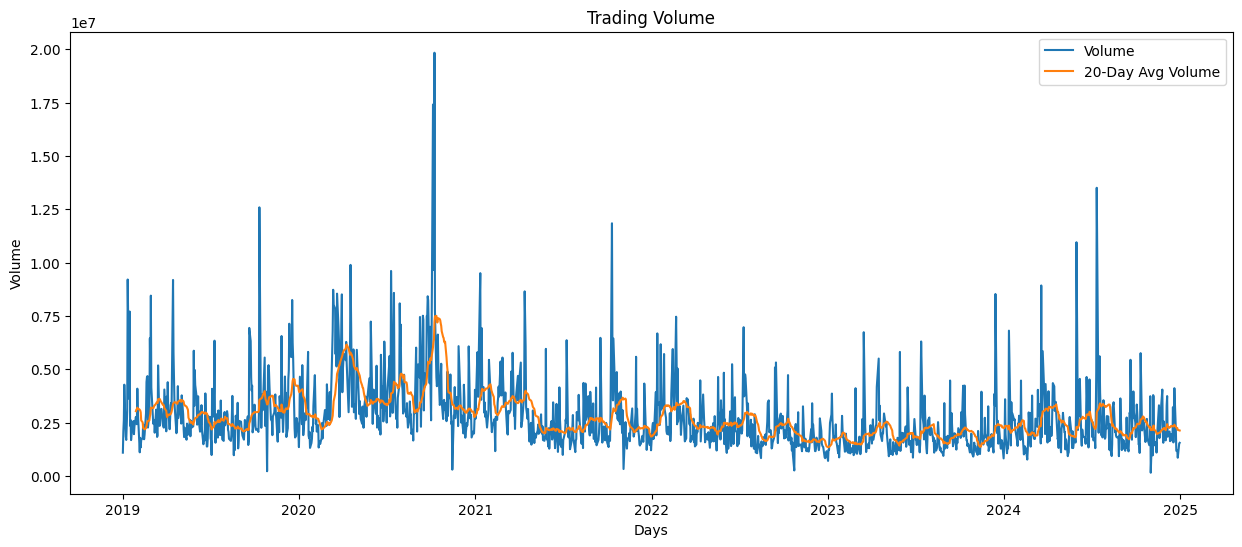

In [34]:
plt.figure(figsize=(15,6))

plt.plot(df["Volume"], label="Volume")
plt.plot(df["Volume_MA20"], label="20-Day Avg Volume")

plt.title("Trading Volume")
plt.xlabel("Days")
plt.ylabel("Volume")

plt.legend()

plt.show()

In [35]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'log_return', 'MA5',
       'MA10', 'MA20', 'Volatility', 'Volume_MA20', 'Volume_Change'],
      dtype='object')


In [37]:
df.head(25)

,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_MA20,Volume_Change
Date,,,,,,,,,,,,,
2019-01-01,1561.000610,1566.907236,1546.397979,1555.422052,1094883.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,1577.817749,1586.964795,1558.703087,1562.804937,2100463.0,0.010773,0.010716,NaN,NaN,NaN,NaN,NaN,0.918436
2019-01-03,1558.662354,1595.579013,1553.042838,1574.290446,2611668.0,-0.012140,-0.012215,NaN,NaN,NaN,NaN,NaN,0.243377
2019-01-04,1539.711792,1559.687786,1510.301540,1558.703382,4280862.0,-0.012158,-0.012233,NaN,NaN,NaN,NaN,NaN,0.639129
2019-01-07,1556.980347,1565.922400,1543.116073,1551.976109,1856423.0,0.011215,0.011153,1558.834570,NaN,NaN,NaN,NaN,-0.566344
2019-01-08,1553.412231,1563.953970,1545.003436,1563.133600,1691756.0,-0.002292,-0.002294,1557.316895,NaN,NaN,NaN,NaN,-0.088701
2019-01-09,1547.997559,1574.290464,1531.385062,1564.774190,2414376.0,-0.003486,-0.003492,1551.352856,NaN,NaN,NaN,NaN,0.427142
2019-01-10,1549.310303,1562.805354,1535.815152,1550.499800,3053461.0,0.000848,0.000848,1549.482446,NaN,NaN,NaN,NaN,0.264700
2019-01-11,1511.572998,1538.193968,1505.379164,1534.092118,9209862.0,-0.024357,-0.024659,1543.854687,NaN,NaN,NaN,NaN,2.016204
